In [127]:
import sys
sys.path.insert(0, '..')

In [128]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from fisher import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [129]:
wid = 72
oversample = 4

nwavels = 15#13#6
npoly=10

n_zernikes = 30

optics = NICMOSFresnelOptics(512, wid, oversample, n_zernikes = n_zernikes, defocus=0., fnumber=80.)

detector = NICMOSDetector(oversample, wid)

ddir = "../data/MAST_2024-09-22T03_37_01.724Z/HST/"

spectrum_basis_f110w = load_spectrum_basis("F110W", nwavels, npoly)


ddir = "../data/MAST_2025-12-15T00_12_09.074Z/HST/"

exposures_single = [
    exposure_from_file(ddir + "n9nk29c8q_cal.fits", SinglePointFit(spectrum_basis_f110w, "F110W"), crop=wid),
    exposure_from_file(ddir + "n9nk29d1q_cal.fits", SinglePointFit(spectrum_basis_f110w, "F110W"), crop=wid),
    #exposure_from_file(ddir + "n8yj49k6q_cal.fits", SinglePointFit(spectrum_basis_f110w, "F110W"), crop=wid),
    #exposure_from_file(ddir + "n8yj49k8q_cal.fits", SinglePointFit(spectrum_basis_f110w, "F110W"), crop=wid),
]


173 93
219 93


/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:159: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)
/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:159: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)


In [130]:
for e in exposures_single:
    print(e.mjd)#*86400)
    print(e.target)
    print(e.filter)
    print(e.exptime)

53920.46725481
U20581
F110W
143.9167
53920.53006731
U20581
F110W
143.9167


In [131]:
params = {
    #"fluxes": {},
    "positions": {},
    "spectrum": {},
    "aberrations": {},

    #"rot": 0.,

    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_scale": {},
    "cold_mask_shear": {},
    "primary_scale": {},
    "primary_rot": {},
    "primary_shear": {},
    "outer_radius": 1.2*0.955,
    "secondary_radius": 0.372*1.2,
    "spider_width": 0.077*1.2,

    "softening": 20.,#0.1,
    "bias": {},
    "jitter": {},

    "defocus": {},#1e5#{}
    "fnumber": 80.,
    "quadrature": {},
}



for idx, exp in enumerate(exposures_single):
    params["positions"][exp.fit.get_key(exp, "positions")] = np.asarray([0.,0.])
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set(np.log10(np.nansum(exp.data)/nwavels))
    params["aberrations"][exp.fit.get_key(exp, "aberrations")] = np.zeros(n_zernikes)
    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.asarray([6.,6.])
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = -45.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -45. + 90. 
    params["primary_scale"][exp.fit.get_key(exp, "primary_scale")] = np.asarray([1.,1.])
    params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])
    params["defocus"][exp.fit.get_key(exp, "defocus")] = 0.
    

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    params["jitter"][exp.fit.get_key(exp, "jitter")] = 7/43*oversample
    params["quadrature"][exp.fit.get_key(exp, "quadrature")] = 0.


model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))
#model_binary = set_array(NICMOSModel(exposures_binary, params, optics, detector))


params = ModelParams(params)

25.04532601423863
21.14641566894373


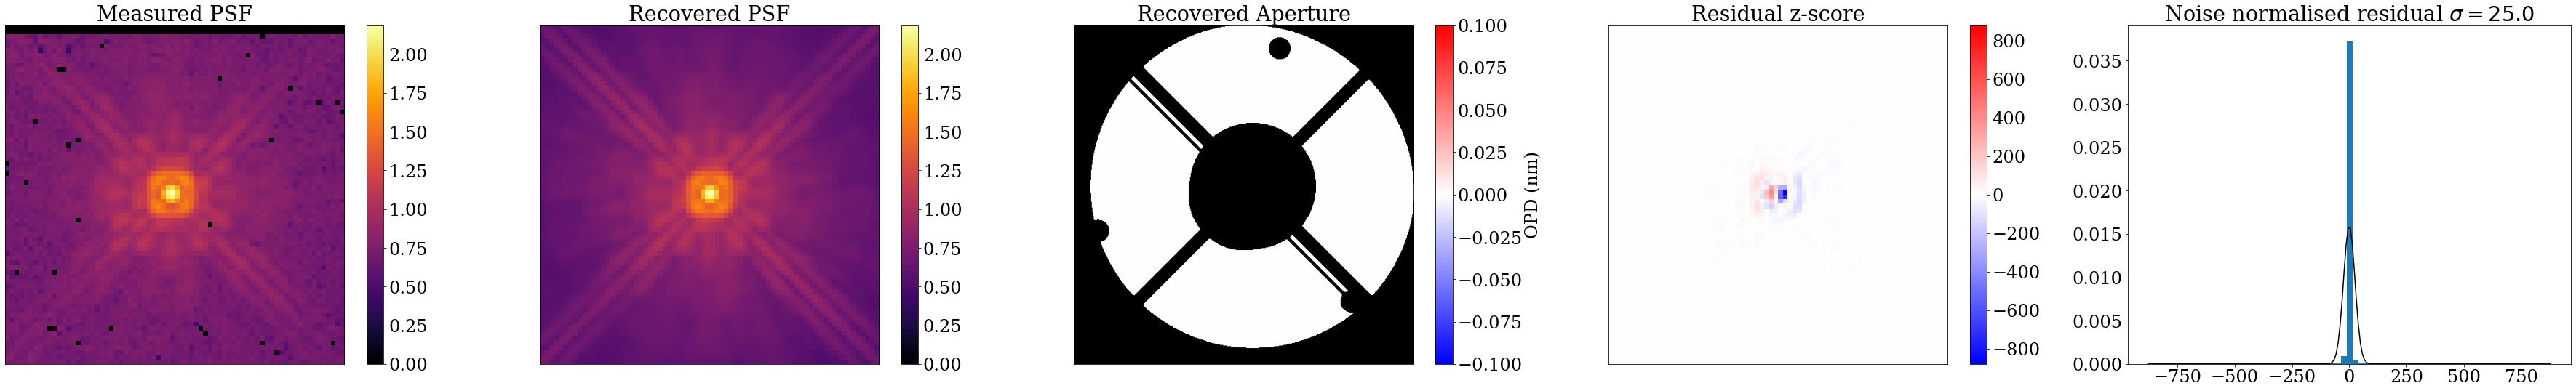

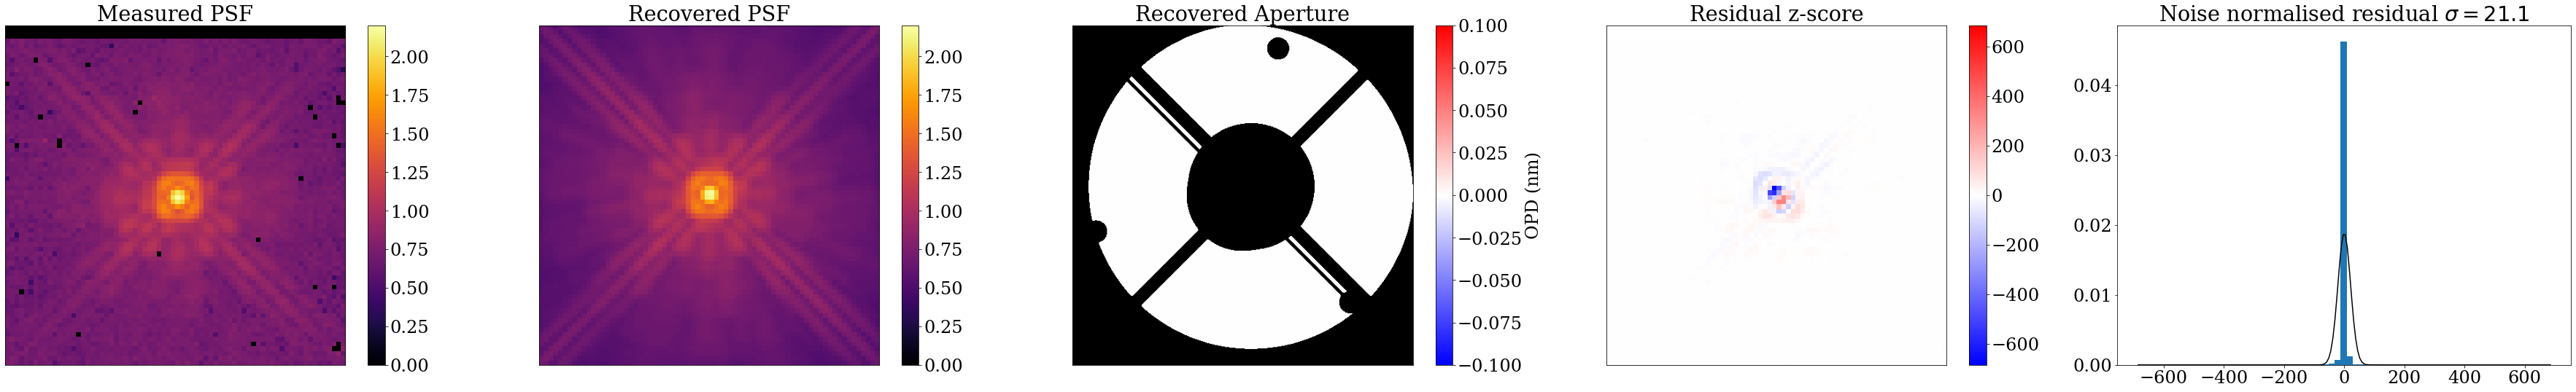

In [132]:
plot_comparison(model_single, params, exposures_single)

In [133]:
def sgd(lr, delay, momentum=0.5):
    return optax.sgd(zdx.optimisation.delay(lr, delay), momentum=momentum)

g = 5e-2

things = {
    "positions": sgd(g*2.5, 0),
    "spectrum": sgd(g*0.2, 10),
    "cold_mask_shift": sgd(g*0.1, 30),
    
    "bias": sgd(g*3, 20),
    "aberrations": sgd(g*0.05, 70),
    #"jitter": sgd(g*1, 120),

    "defocus": sgd(g*5, 30),
    #"fnumber": sgd(g*3, 100),
    "cold_mask_shear": sgd(g*0.5, 100),

    "quadrature": sgd(g*20, 900),
}

things_start = {
    "positions": sgd(g*5, 0),
}

groups = list(things.keys())

In [134]:
orig_params = params.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [135]:
opt_params

{'positions': {'n9nk29c8q': Array([0., 0.], dtype=float64),
  'n9nk29d1q': Array([0., 0.], dtype=float64)}}

In [136]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things_start, 10)

[1.21869444e-07 2.65214899e-07 1.94977719e-07 1.87442924e-07]


  0%|          | 0/10 [00:00<?, ?it/s]

4.543869152339234
4.7913477070571115


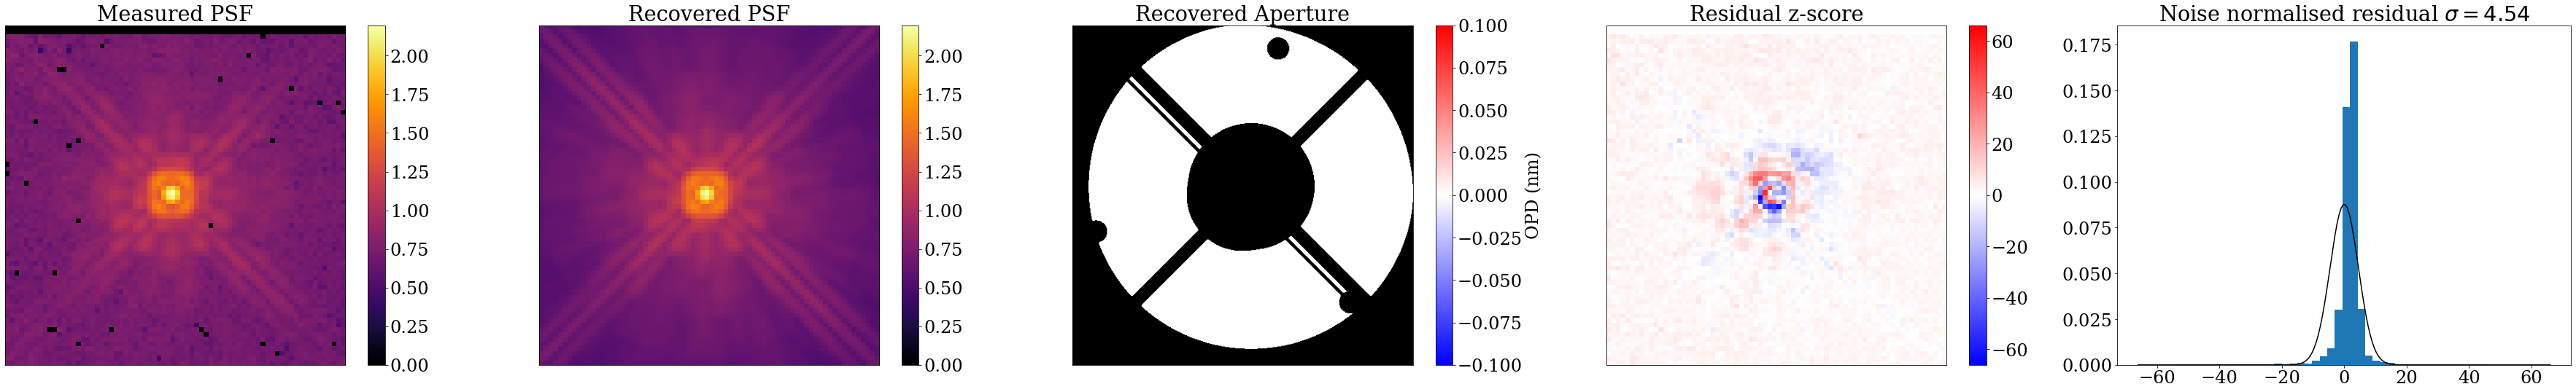

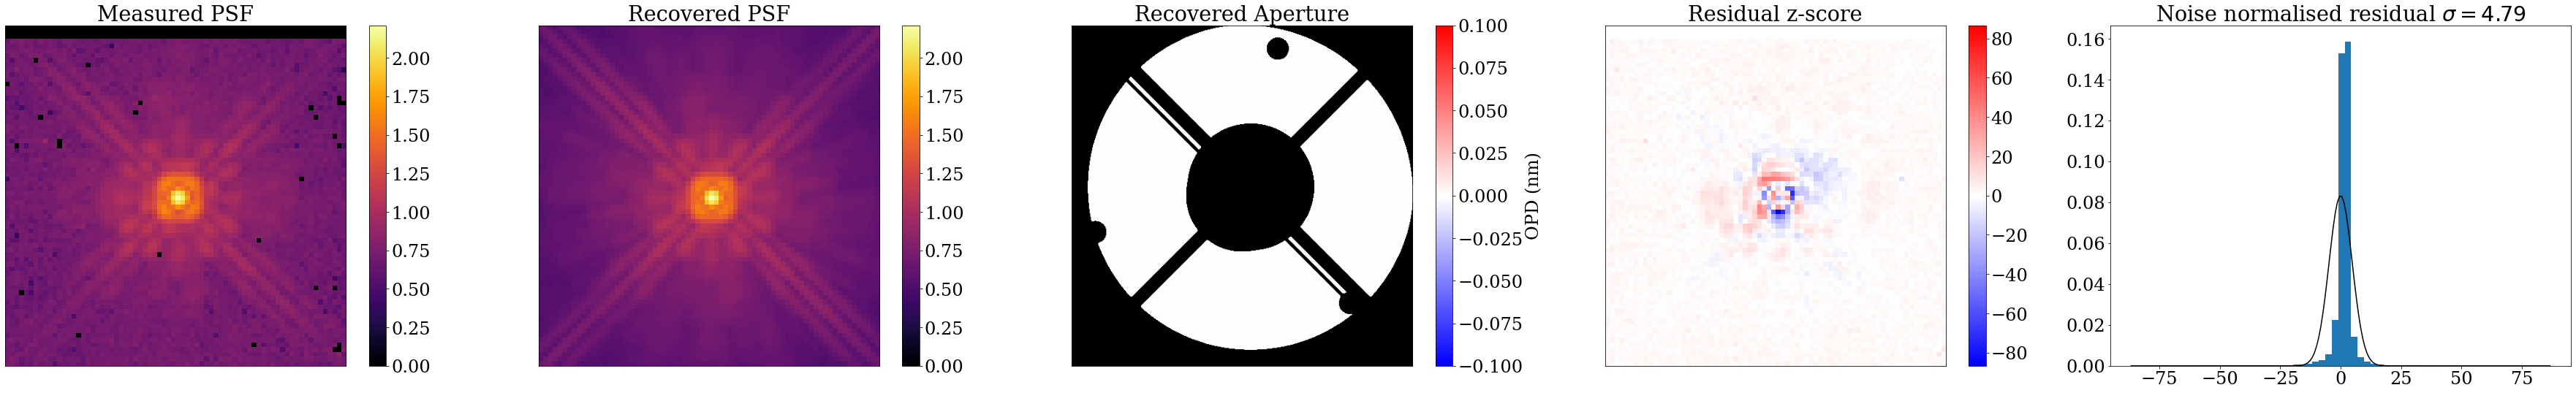

In [137]:
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single)

In [138]:
orig_params = params.params | params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things})

In [139]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things, 1000, nbatches=10)

[8.10834366e-01 3.64256620e-02 5.40886673e-03 5.20230498e-03
 3.92276247e-03 3.90029911e-03 3.62742721e-02 1.76292648e-02
 4.06662330e-02 1.02777077e-01 1.02950373e-01 1.02516492e-02
 1.07259370e-02 4.99377796e-03 5.02401447e-03 1.28012983e-02
 1.25566362e-02 9.57750817e-02 9.30952640e-01 4.72931533e-02
 1.62961922e+00 7.05689353e-02 2.61256047e-01 2.78500822e-01
 1.86547231e-02 1.67104542e-02 1.48201612e-02 1.35571214e-02
 1.41906259e-02 1.49145312e-02 1.07517287e+00 3.57285945e-02
 5.06379684e-03 4.98345553e-03 3.74375221e-03 3.64585340e-03
 3.40940245e-02 1.56238834e-02 3.84511327e-02 7.05183320e-02
 7.57017920e-02 1.00758476e-02 1.02277756e-02 4.73477781e-03
 4.78406891e-03 1.18895796e-02 1.18657414e-02 8.56468339e-02
 3.44595736e+00 3.76879781e-02 2.78176486e-01 5.80732102e-02
 1.75578059e-01 3.94172034e+00 1.75026569e-02 1.68319596e-02
 1.33409008e-02 1.29367693e-02 1.31695410e-02 1.32452349e-02
 9.57022834e-08 1.04920332e-07 5.42612096e-04 5.26523373e-04
 9.21469006e-04 1.050316

  0%|          | 0/1000 [00:00<?, ?it/s]

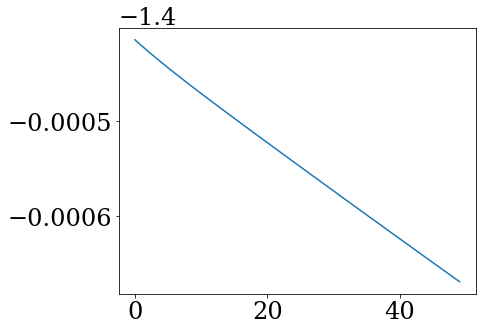

In [140]:
plt.plot(np.asarray(losses[-50:])/(len(exposures_single)*wid**2))

In [141]:
params_history_relative = [jax.tree.map(lambda x, y: x-y, x, params_history[0]) for x in params_history]

8
0.9999091935487514
0.9997885933633661


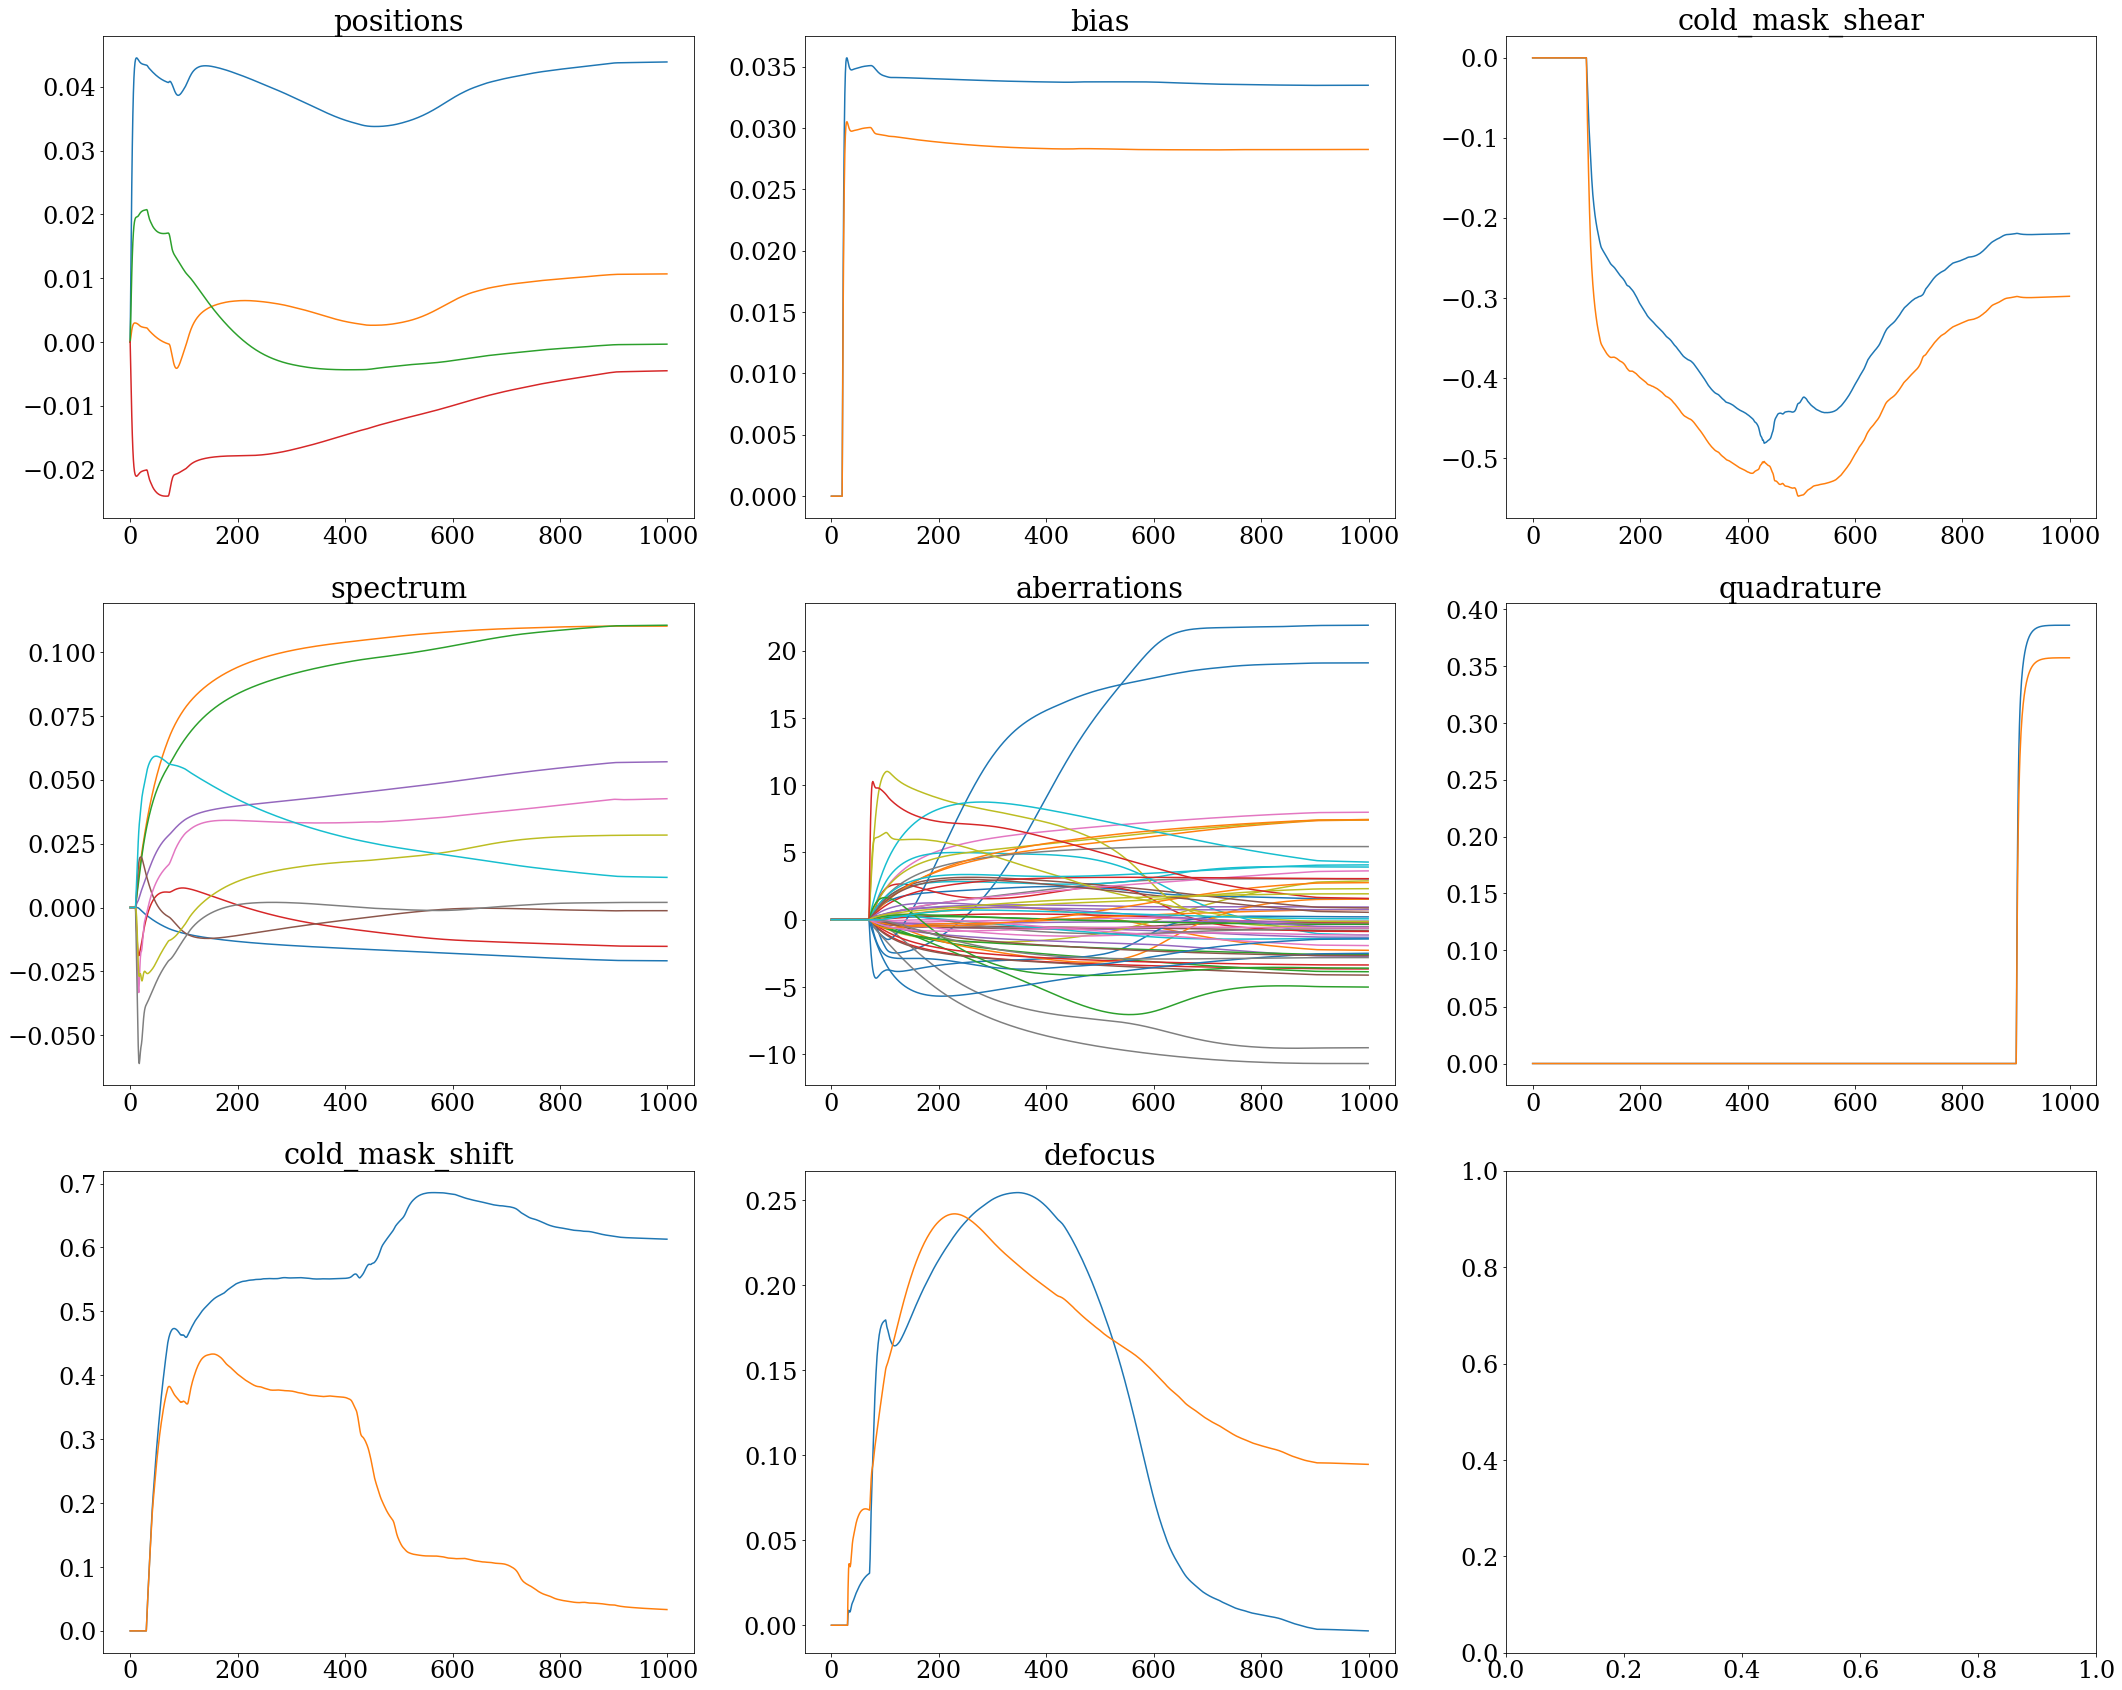

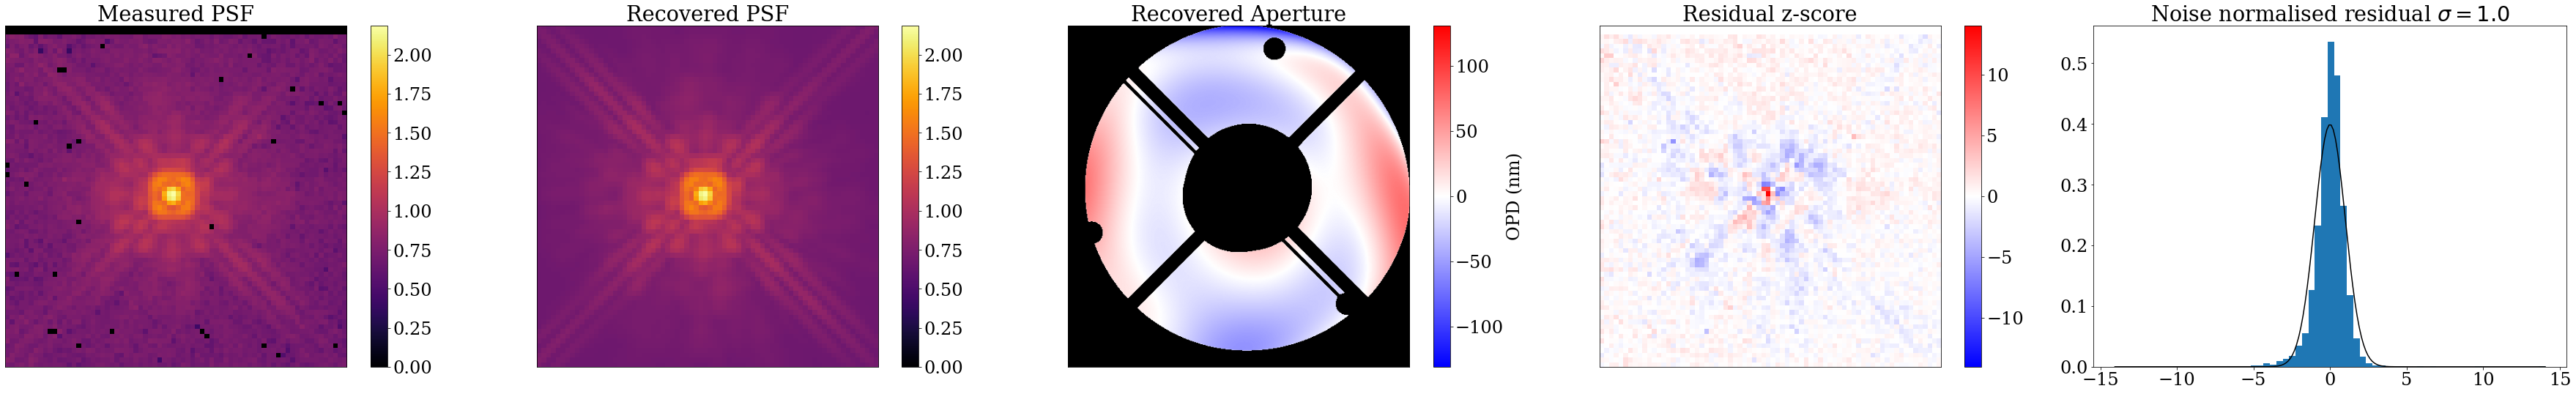

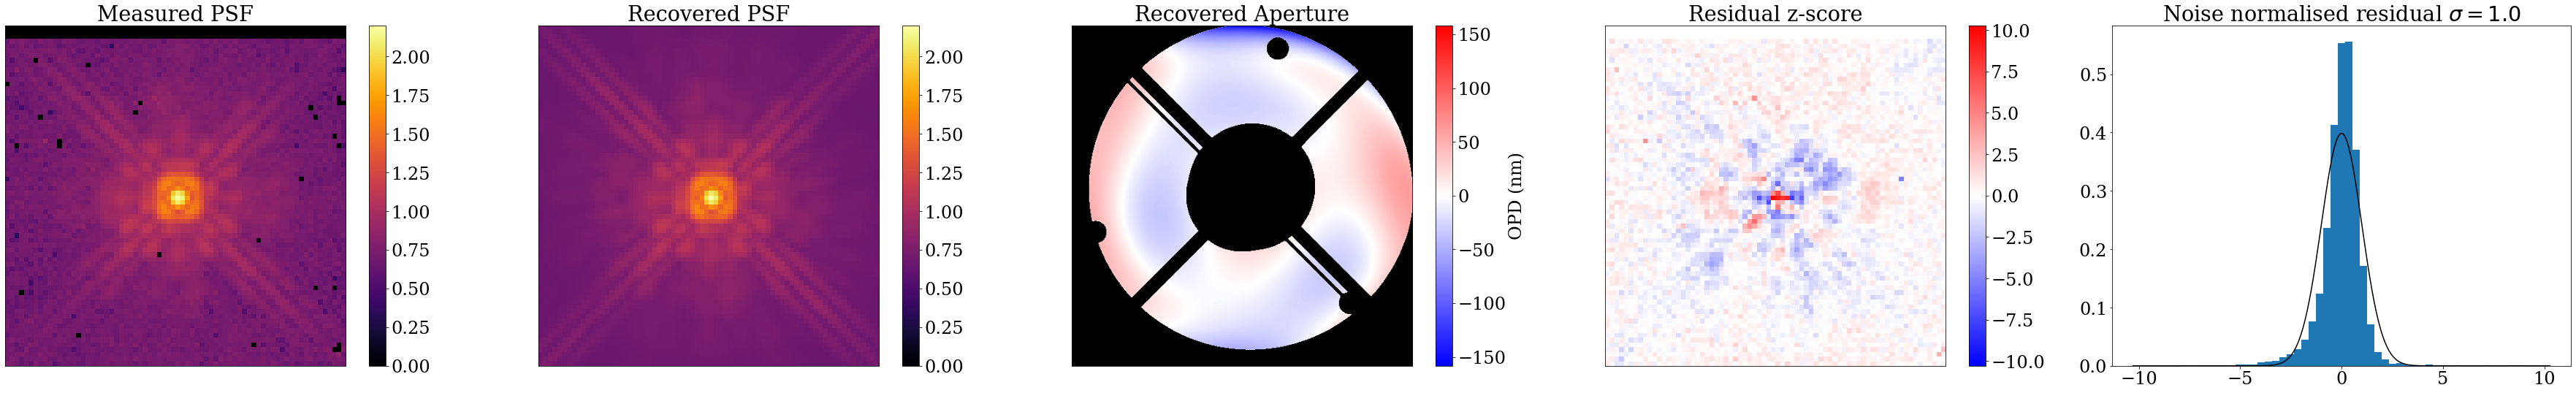

In [142]:
plot_params(params_history_relative, groups, xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, quadrature=True)

In [143]:
final_params = optimise_optimistix(params_history[-1], model_single, exposures_single, project=True, diag=True)

In [144]:
final_params.params

{'aberrations': {'n9nk29c8q': Array([ 11.72969939,  -8.41243702, -13.08459473,   1.19879204,
          -7.04195467,  -9.27199313,  16.13141918,  -2.40003819,
          -5.57633364, -11.86556797,   0.72757007,  12.61811062,
         -12.51708221,  -6.27828694,  -3.35630475,  -1.53675134,
           2.29481684,   1.10676022,  -8.23407461,  -0.82294814,
          -0.67291832,  -5.7397577 ,  -4.30496865,  -0.45159015,
          -6.9197944 ,  -0.36938517,  -2.68313146,  -1.5272818 ,
           3.5620611 ,  -0.98680263], dtype=float64),
  'n9nk29d1q': Array([  4.75265802,  -7.7722009 , -20.84033361,   5.40203965,
          -4.03868365, -18.81454383,  21.43923024,  -3.44226214,
          -6.66840711, -11.56315634,   0.5537917 ,  13.22424155,
         -10.08034217,  -6.590953  ,  -1.25676647,  -4.72617626,
           1.05519922,   1.52522209,  -9.2910587 ,  -2.76132092,
           0.95666709,  -6.80322764,  -3.04569413,   0.34688111,
          -5.72533189,   0.5630275 ,  -1.11360922,  -4.99023

In [145]:
#sol.stats

0.9999276752960791
0.9998128887050429


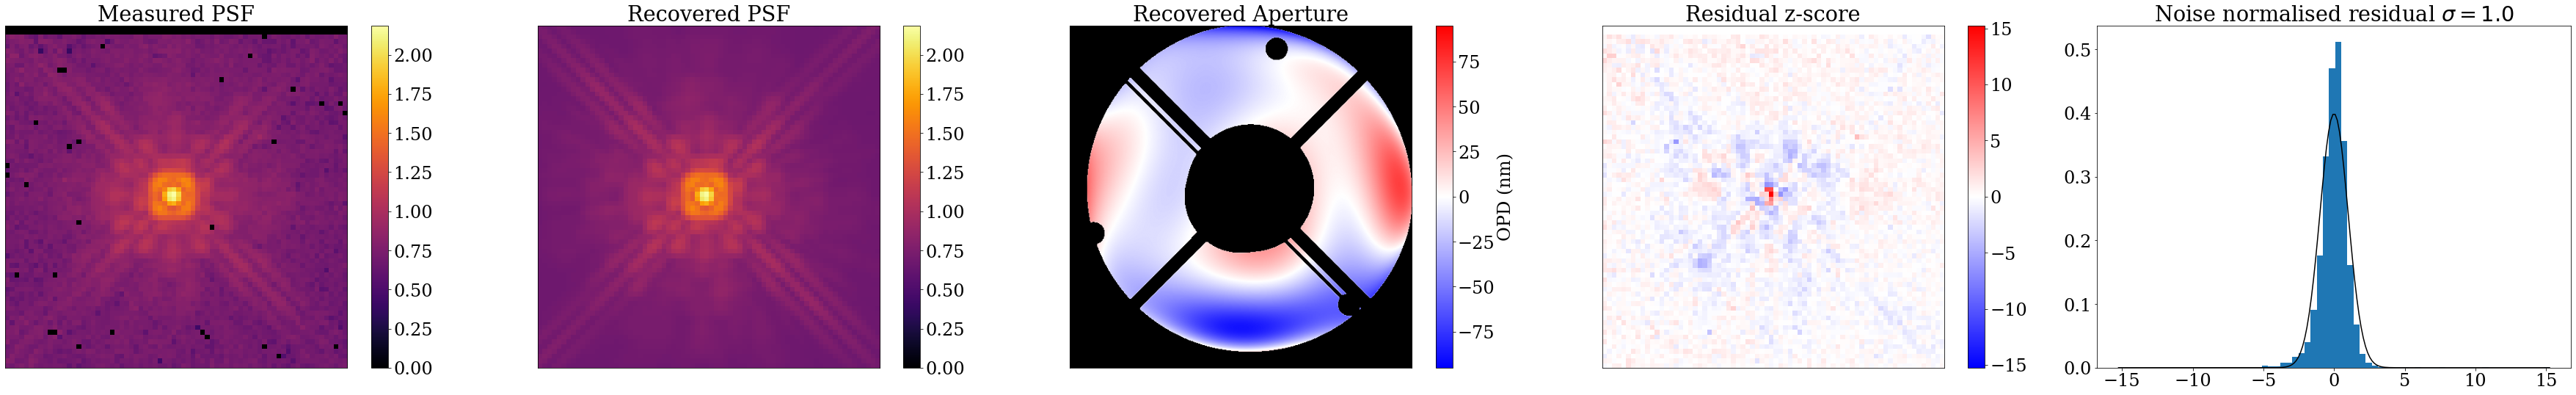

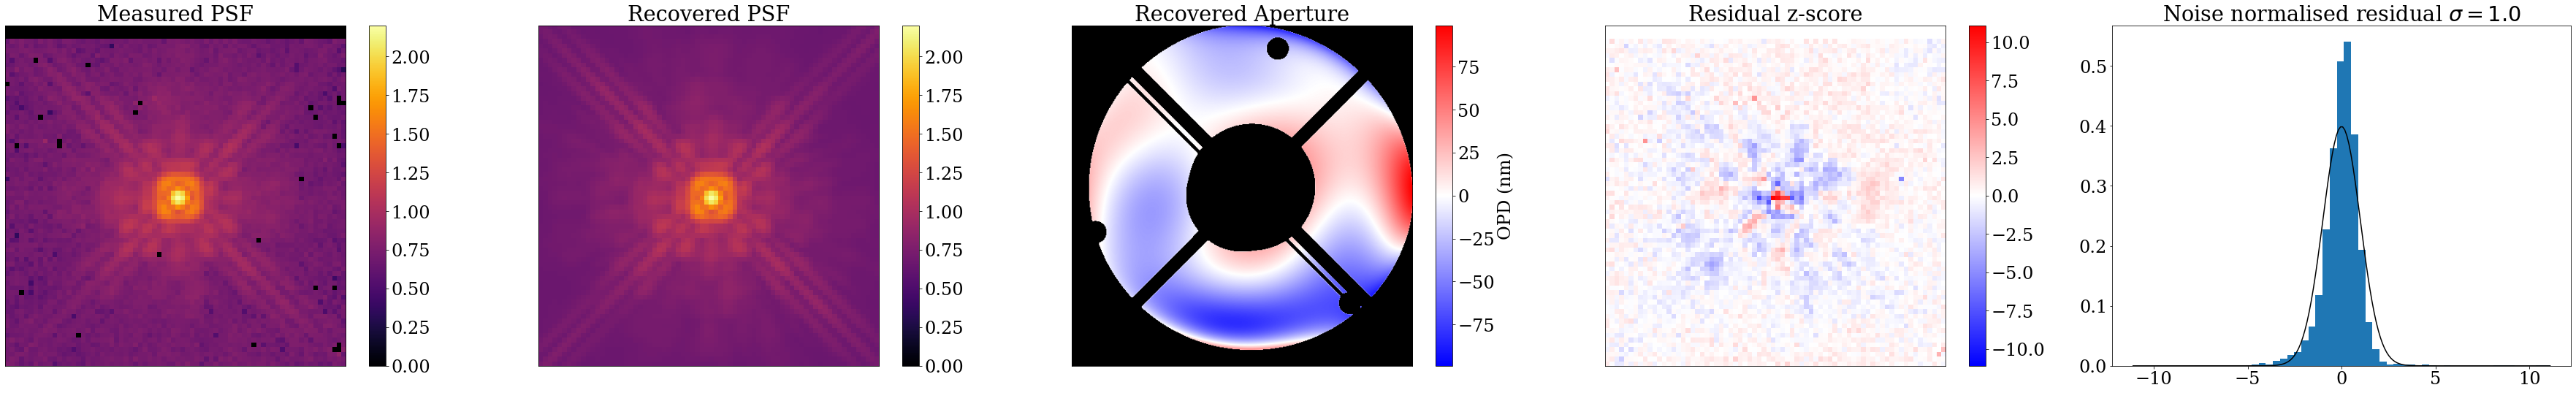

In [146]:
plot_comparison(final_params.inject((model_single)), final_params, exposures_single, quadrature=True)

In [147]:
# calculate spectrum

In [148]:
def loss_fn(params, exposures, model):
    mdl = params.inject(model)
    return np.nansum(np.asarray([posterior(mdl,exposure) for exposure in exposures]))


In [149]:
f = lambda params: loss_fn(ModelParams(params), exposures_single, final_params.inject((model_single)))
F, unflatten = zdx.batching.hessian(f, final_params, nbatches=5*len(exposures_single))

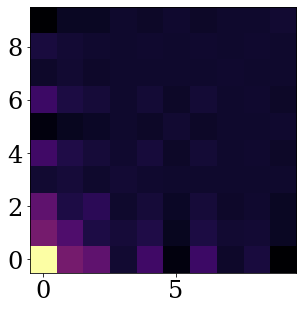

In [150]:
plt.imshow(F[-npoly:, -npoly:])

In [151]:
cov_f110w = np.linalg.inv(F)[-npoly:, -npoly:]#+fsh['n8yj02wyq.spectrum'])
spectrum_err = np.diag(np.sqrt(np.abs(cov_f110w)))


In [152]:
final_params

ModelParams(
  params={
    'aberrations': {'n9nk29c8q': f64[30], 'n9nk29d1q': f64[30]},
    'bias': {'n9nk29c8q': f64[], 'n9nk29d1q': f64[]},
    'cold_mask_shear': {'global': f64[2]},
    'cold_mask_shift': {'global': f64[2]},
    'defocus': {'n9nk29c8q': f64[], 'n9nk29d1q': f64[]},
    'positions': {'n9nk29c8q': f64[2], 'n9nk29d1q': f64[2]},
    'quadrature': {'n9nk29c8q': f64[], 'n9nk29d1q': f64[]},
    'spectrum': {'U20581_F110W': f64[10]}
  }
)

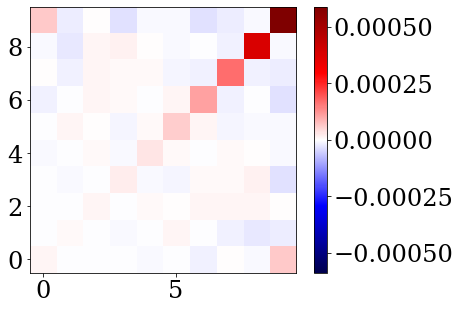

In [153]:
plt.imshow(cov_f110w, cmap='seismic', vmin=-np.max(np.abs(cov_f110w)), vmax=np.max(np.abs(cov_f110w)))
plt.colorbar()


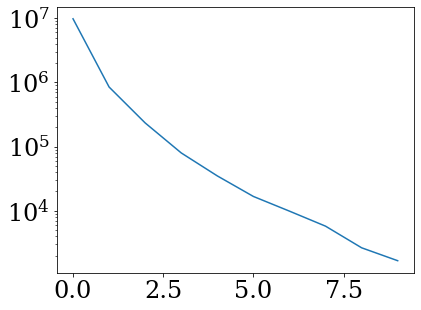

In [154]:
vals, vects = np.linalg.eig(F[-npoly:, -npoly:])#+fsh['n8yj02wyq.spectrum'])

order = np.argsort(vals)[::-1]

#plt.figure(figsize=(10,10))
#plt.xlabel("Coefficient")

#for i in range(5):
#    plt.plot(np.arange(npoly),np.real(vects[:,order[i]]), label=f"{i}")
#plt.legend()

plt.semilogy(np.sort(np.real(vals))[::-1])

Text(0.5, 0, 'Wavelength (um)')

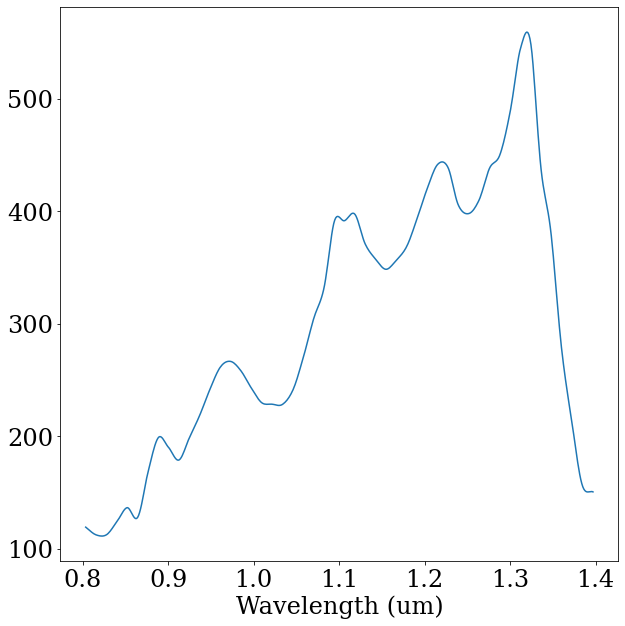

In [155]:
plt.figure(figsize=(10,10))

nw = 500
wv, filt = calc_throughput("F110W", nwavels=nw)
big_basis = load_spectrum_basis("F110W", nw, npoly)

spec = CombinedBasisSpectrum(wv, filt, final_params.get("spectrum.U20581_F110W"), big_basis)


sp = spec.spec_weights()/spec.flux*spec.proper_flux()#/(wv*1e6)

plt.plot(wv*1e6, sp)

plt.xlabel("Wavelength (um)")


In [156]:
fname = "2M1439.fits"
data = fits.getdata(fname, ext=0).astype(np.float32)

Text(0.5, 0, 'Wavelength (um)')

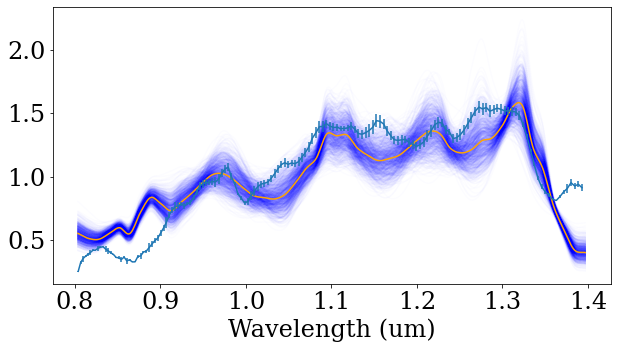

In [157]:
plt.figure(figsize=(10,5))




nw = 500
wv, filt = calc_throughput("F110W", nwavels=nw)
big_basis = load_spectrum_basis("F110W", nw, npoly)

spec = CombinedBasisSpectrum(wv, filt, final_params.get("spectrum.U20581_F110W"), big_basis)


sp = spec.spec_weights()/spec.flux*spec.proper_flux()/(wv*1e6)

smax = np.mean(sp)

sp = sp/smax

plt.plot(wv*1e6, sp, color='orange')

for i in range(1000):
    coeffs = numpy.random.multivariate_normal(final_params.get("spectrum.U20581_F110W"), (cov_f110w))
    spec = CombinedBasisSpectrum(wv, filt, coeffs, big_basis)#CombinedFourierSpectrum(wv, filt, coeffs)
    plt.plot(wv*1e6, spec.spec_weights()/spec.flux*spec.proper_flux()/(wv*1e6)/smax, color='b', alpha=0.01, zorder=0)


wv_range = (data[0]*1e-6 > np.min(wv)) & (data[0]*1e-6 < np.max(wv))
plt.errorbar(data[0][wv_range], data[1][wv_range]/np.mean(data[1][wv_range]), data[2][wv_range]/np.mean(data[1][wv_range]))

plt.xlabel("Wavelength (um)")


In [159]:
final_params.params

{'aberrations': {'n9nk29c8q': Array([ 11.72969939,  -8.41243702, -13.08459473,   1.19879204,
          -7.04195467,  -9.27199313,  16.13141918,  -2.40003819,
          -5.57633364, -11.86556797,   0.72757007,  12.61811062,
         -12.51708221,  -6.27828694,  -3.35630475,  -1.53675134,
           2.29481684,   1.10676022,  -8.23407461,  -0.82294814,
          -0.67291832,  -5.7397577 ,  -4.30496865,  -0.45159015,
          -6.9197944 ,  -0.36938517,  -2.68313146,  -1.5272818 ,
           3.5620611 ,  -0.98680263], dtype=float64),
  'n9nk29d1q': Array([  4.75265802,  -7.7722009 , -20.84033361,   5.40203965,
          -4.03868365, -18.81454383,  21.43923024,  -3.44226214,
          -6.66840711, -11.56315634,   0.5537917 ,  13.22424155,
         -10.08034217,  -6.590953  ,  -1.25676647,  -4.72617626,
           1.05519922,   1.52522209,  -9.2910587 ,  -2.76132092,
           0.95666709,  -6.80322764,  -3.04569413,   0.34688111,
          -5.72533189,   0.5630275 ,  -1.11360922,  -4.99023